# Assignment 3: Text Cleaning, Lemmatization, and TF-IDF

**Problem Statement:** Perform text cleaning, perform lemmatization (any method), remove stop words (any method), label encoding. Create representations using TF-IDF. Save outputs.

**Dataset:** News Dataset (News_dataset.pickle)
- 2,225 news articles
- 5 categories: sport, business, politics, tech, entertainment
- Text column: 'Content'

## 1. Import Required Libraries

In [1]:
# Install required packages
!pip install pandas numpy scikit-learn nltk matplotlib seaborn -q

import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Set display options
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load the News dataset
df = pd.read_pickle('News_dataset.pickle')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(df.head(3))

print(f"\nDataset Info:")
df.info()

Dataset shape: (2225, 6)

Columns: ['File_Name', 'Content', 'Category', 'Complete_Filename', 'id', 'News_length']

First 3 rows:


,File_Name,Content,Category,Complete_Filename,id,News_length
0,001.txt,Ad sales boost Time Warner profit\r\n\r\nQuarterly profits at US media giant TimeWarner jumped 7...,business,001.txt-business,1,2569
1,002.txt,Dollar gains on Greenspan speech\r\n\r\nThe dollar has hit its highest level against the euro in...,business,002.txt-business,1,2257
2,003.txt,Yukos unit buyer faces loan claim\r\n\r\nThe owners of embattled Russian oil giant Yukos are to ...,business,003.txt-business,1,1557



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   File_Name          2225 non-null   object
 1   Content            2225 non-null   object
 2   Category           2225 non-null   object
 3   Complete_Filename  2225 non-null   object
 4   id                 2225 non-null   int64 
 5   News_length        2225 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 104.4+ KB


Missing values:
File_Name            0
Content              0
Category             0
Complete_Filename    0
id                   0
News_length          0
dtype: int64

Category distribution:
Category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


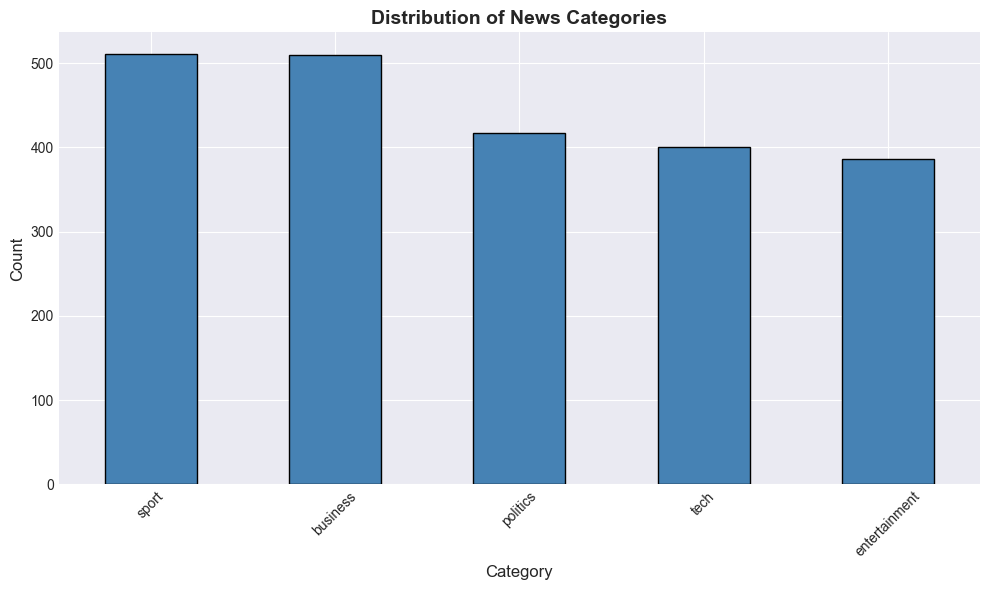

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\nCategory distribution:")
print(df['Category'].value_counts())

# Visualize category distribution
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of News Categories', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Display sample content from each category
print("Sample articles from each category:\n")
for category in df['Category'].unique():
    sample = df[df['Category'] == category].iloc[0]
    print(f"\n{'='*80}")
    print(f"Category: {category.upper()}")
    print(f"{'='*80}")
    print(sample['Content'][:300] + "...\n")

Sample articles from each category:


Category: BUSINESS
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and ...


Category: ENTERTAINMENT
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richard Wentworth, who...


Category: POLITICS
Labour plans maternity pay rise

Maternity pay for new mothers is to rise by Â£1,400 as part of new proposals announced by the Trade and Industry Secretary Patricia Hewitt.

It would mean paid leave would be increased to nine months by 2007, Ms Hewitt told GMTV's Sunday programme. Other plans in

## 3. Text Cleaning

In [5]:
def clean_text(text):
    """
    Clean text by:
    1. Converting to lowercase
    2. Removing special characters, numbers, and punctuation
    3. Removing extra whitespace
    4. Removing URLs and email addresses
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply text cleaning
print("Performing text cleaning...")
df['cleaned_text'] = df['Content'].apply(clean_text)

print("\n✓ Text cleaning complete!")
print("\nExample:")
print(f"Original (first 200 chars):\n{df['Content'].iloc[0][:200]}...")
print(f"\nCleaned (first 200 chars):\n{df['cleaned_text'].iloc[0][:200]}...")

Performing text cleaning...

✓ Text cleaning complete!

Example:
Original (first 200 chars):
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now ...

Cleaned (first 200 chars):
ad sales boost time warner profit quarterly profits at us media giant timewarner jumped to bn m for the three months to december from m yearearlier the firm which is now one of the biggest investors i...


## 4. Tokenization

In [6]:
# Tokenize the cleaned text
print("Tokenizing text...")
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

print("\n✓ Tokenization complete!")
print("\nExample tokens from first document:")
print(df['tokens'].iloc[0][:30])

# Statistics
df['num_tokens'] = df['tokens'].apply(len)
print(f"\nToken statistics:")
print(df['num_tokens'].describe())

Tokenizing text...

✓ Tokenization complete!

Example tokens from first document:
['ad', 'sales', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profits', 'at', 'us', 'media', 'giant', 'timewarner', 'jumped', 'to', 'bn', 'm', 'for', 'the', 'three', 'months', 'to', 'december', 'from', 'm', 'yearearlier', 'the', 'firm', 'which', 'is']

Token statistics:
count    2225.000000
mean      377.189663
std       235.223558
min        88.000000
25%       240.000000
50%       327.000000
75%       465.000000
max      4401.000000
Name: num_tokens, dtype: float64


## 5. Remove Stop Words

In [7]:
# Get English stop words
stop_words = set(stopwords.words('english'))

print(f"Total stop words: {len(stop_words)}")
print(f"\nSample stop words: {list(stop_words)[:20]}")

# Remove stop words
def remove_stopwords(tokens):
    """Remove stop words from token list"""
    return [word for word in tokens if word not in stop_words and len(word) > 2]

print("\nRemoving stop words...")
df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

print("\n✓ Stop words removed!")
print("\nComparison for first document:")
print(f"Before: {len(df['tokens'].iloc[0])} tokens")
print(f"After: {len(df['tokens_no_stop'].iloc[0])} tokens")
print(f"\nTokens after removing stop words:")
print(df['tokens_no_stop'].iloc[0][:30])

Total stop words: 198

Sample stop words: ['more', "needn't", 'once', 'that', 'for', "wouldn't", 'is', 'himself', 'doesn', 'same', "i'd", "haven't", 'ma', "shan't", 'an', 'her', 'they', 'into', 'ours', "she'll"]

Removing stop words...

✓ Stop words removed!

Comparison for first document:
Before: 408 tokens
After: 230 tokens

Tokens after removing stop words:
['sales', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profits', 'media', 'giant', 'timewarner', 'jumped', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest', 'investors', 'google', 'benefited', 'sales', 'highspeed', 'internet', 'connections', 'higher', 'advert', 'sales', 'timewarner', 'said']


## 6. Lemmatization

In [8]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize tokens
def lemmatize_tokens(tokens):
    """Lemmatize list of tokens"""
    return [lemmatizer.lemmatize(word) for word in tokens]

print("Performing lemmatization...")
df['lemmatized_tokens'] = df['tokens_no_stop'].apply(lemmatize_tokens)

print("\n✓ Lemmatization complete!")
print("\nExample - Before and After Lemmatization:")
print(f"Before: {df['tokens_no_stop'].iloc[0][:20]}")
print(f"After:  {df['lemmatized_tokens'].iloc[0][:20]}")

# Create final processed text
df['processed_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

print("\nFinal processed text (first 200 chars):")
print(df['processed_text'].iloc[0][:200] + "...")

Performing lemmatization...

✓ Lemmatization complete!

Example - Before and After Lemmatization:
Before: ['sales', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profits', 'media', 'giant', 'timewarner', 'jumped', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest', 'investors', 'google']
After:  ['sale', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profit', 'medium', 'giant', 'timewarner', 'jumped', 'three', 'month', 'december', 'yearearlier', 'firm', 'one', 'biggest', 'investor', 'google']

Final processed text (first 200 chars):
sale boost time warner profit quarterly profit medium giant timewarner jumped three month december yearearlier firm one biggest investor google benefited sale highspeed internet connection higher adve...


## 7. Text Processing Pipeline Summary

In [9]:
# Show complete pipeline for one document
doc_idx = 0

print("="*100)
print("TEXT PROCESSING PIPELINE - EXAMPLE")
print("="*100)

print(f"\n1. ORIGINAL TEXT:")
print(df['Content'].iloc[doc_idx][:300] + "...")

print(f"\n2. AFTER CLEANING:")
print(df['cleaned_text'].iloc[doc_idx][:300] + "...")

print(f"\n3. AFTER TOKENIZATION:")
print(df['tokens'].iloc[doc_idx][:30])

print(f"\n4. AFTER REMOVING STOP WORDS:")
print(df['tokens_no_stop'].iloc[doc_idx][:30])

print(f"\n5. AFTER LEMMATIZATION:")
print(df['lemmatized_tokens'].iloc[doc_idx][:30])

print(f"\n6. FINAL PROCESSED TEXT:")
print(df['processed_text'].iloc[doc_idx][:300] + "...")

print("\n" + "="*100)

TEXT PROCESSING PIPELINE - EXAMPLE

1. ORIGINAL TEXT:
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and ...

2. AFTER CLEANING:
ad sales boost time warner profit quarterly profits at us media giant timewarner jumped to bn m for the three months to december from m yearearlier the firm which is now one of the biggest investors in google benefited from sales of highspeed internet connections and higher advert sales timewarner s...

3. AFTER TOKENIZATION:
['ad', 'sales', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profits', 'at', 'us', 'media', 'giant', 'timewarner', 'jumped', 'to', 'bn', 'm', 'for', 'the', 'three', 'months', 'to', 'december', 'from', 'm', 'yearearlier', 'the', 'firm', 'which', 'is']

4. AFTER REMOVING STOP WORDS:
['sales', 

## 8. Label Encoding

In [10]:
# Perform label encoding on categories
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['Category'])

print("="*80)
print("LABEL ENCODING")
print("="*80)

# Show mapping
print("\nCategory to Label Mapping:")
for i, category in enumerate(label_encoder.classes_):
    count = len(df[df['Category'] == category])
    print(f"{category:<20} -> {i:<5} ({count} documents)")

print("\nSample of encoded labels:")
display(df[['Category', 'category_encoded']].head(10))

LABEL ENCODING

Category to Label Mapping:
business             -> 0     (510 documents)
entertainment        -> 1     (386 documents)
politics             -> 2     (417 documents)
sport                -> 3     (511 documents)
tech                 -> 4     (401 documents)

Sample of encoded labels:


,Category,category_encoded
0,business,0
1,business,0
2,business,0
3,business,0
4,business,0
5,business,0
6,business,0
7,business,0
8,business,0
9,business,0


## 9. Create TF-IDF Representations

In [11]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,      # Limit to top 1000 features
    min_df=2,               # Minimum document frequency
    max_df=0.95,            # Maximum document frequency
    ngram_range=(1, 2)      # Unigrams and bigrams
)

# Fit and transform
print("Creating TF-IDF representations...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n" + "="*80)
print("TF-IDF REPRESENTATION")
print("="*80)
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Number of documents: {tfidf_matrix.shape[0]}")
print(f"Number of features: {tfidf_matrix.shape[1]}")
print(f"Matrix type: {type(tfidf_matrix)}")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}")

print(f"\nSample features (first 20):")
print(list(feature_names[:20]))

Creating TF-IDF representations...

TF-IDF REPRESENTATION
Matrix shape: (2225, 1000)
Number of documents: 2225
Number of features: 1000
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 92.19%

Sample features (first 20):
['ability', 'able', 'access', 'according', 'account', 'accused', 'across', 'act', 'action', 'activity', 'actor', 'actress', 'actually', 'add', 'added', 'address', 'admitted', 'affair', 'africa', 'age']


### 9.1 Analyze TF-IDF Scores

In [12]:
# Convert to DataFrame for analysis
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

print("TF-IDF DataFrame (first 5 documents, first 10 features):")
display(tfidf_df.iloc[:5, :10])

# Get top TF-IDF words for sample documents
print("\nTop 10 TF-IDF words for sample documents:\n")
for i in range(3):
    top_words = tfidf_df.iloc[i].nlargest(10)
    print(f"Document {i} (Category: {df['Category'].iloc[i]}):")
    for word, score in top_words.items():
        if score > 0:
            print(f"  {word}: {score:.4f}")
    print()

TF-IDF DataFrame (first 5 documents, first 10 features):


,ability,able,access,according,account,accused,across,act,action,activity
0,0.0,0.0,0.0,0.0,0.113651,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.170937,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.062866,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0



Top 10 TF-IDF words for sample documents:

Document 0 (Category: business):
  profit: 0.6038
  revenue: 0.2477
  quarter: 0.2240
  sale: 0.2223
  internet: 0.2190
  stake: 0.2096
  fourth: 0.1807
  google: 0.1542
  customer: 0.1197
  rose: 0.1168

Document 1 (Category: business):
  deficit: 0.5139
  dollar: 0.4123
  recent: 0.1950
  account: 0.1709
  current: 0.1524
  month: 0.1423
  he: 0.1308
  china: 0.1273
  speech: 0.1260
  budget: 0.1216

Document 2 (Category: business):
  yukos: 0.6419
  unit: 0.2512
  claim: 0.2484
  sale: 0.2328
  ask: 0.1769
  bought: 0.1637
  forced: 0.1560
  production: 0.1535
  tax: 0.1477
  pay: 0.1388



### 9.2 Visualize Top TF-IDF Features

Top 20 features by average TF-IDF score:
said          0.067021
year          0.035264
would         0.031238
game          0.028972
film          0.028665
new           0.026986
people        0.026854
also          0.026741
one           0.024086
last          0.022564
company       0.022033
world         0.021931
time          0.021444
could         0.021440
first         0.021248
government    0.020754
firm          0.020666
two           0.019571
say           0.019553
best          0.018723
dtype: float64


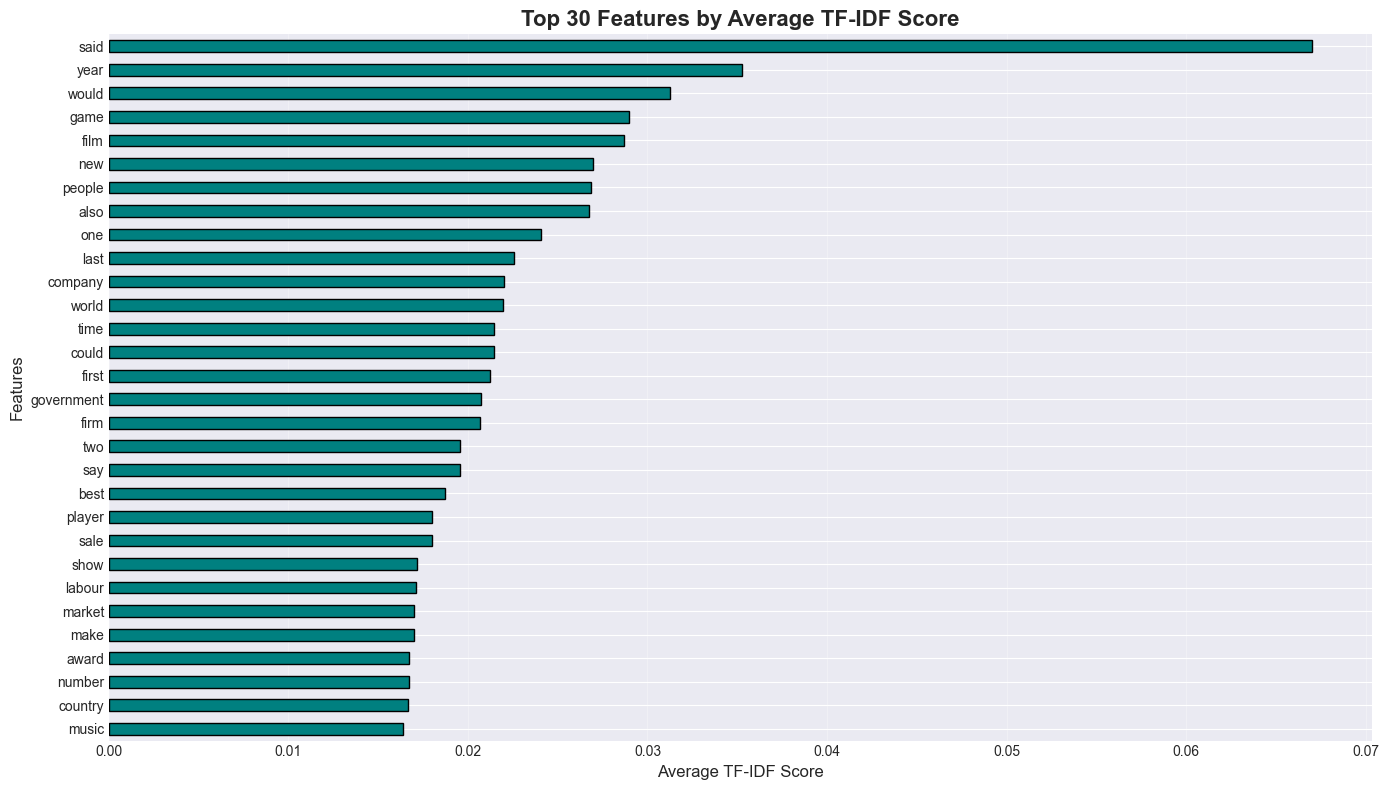

In [13]:
# Calculate average TF-IDF scores
avg_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False)

print("Top 20 features by average TF-IDF score:")
print(avg_tfidf.head(20))

# Plot
plt.figure(figsize=(14, 8))
avg_tfidf.head(30).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 30 Features by Average TF-IDF Score', fontsize=16, fontweight='bold')
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 Category-wise TF-IDF Analysis

In [14]:
# Find top TF-IDF terms for each category
print("Top 10 TF-IDF terms for each category:\n")

for category in df['Category'].unique():
    # Get indices for this category
    cat_indices = df[df['Category'] == category].index
    
    # Calculate average TF-IDF for this category
    cat_tfidf = tfidf_df.iloc[cat_indices].mean(axis=0).sort_values(ascending=False)
    
    print(f"{category.upper()}:")
    print(f"  {', '.join(cat_tfidf.head(10).index.tolist())}")
    print()

Top 10 TF-IDF terms for each category:

BUSINESS:
  said, company, firm, market, bank, year, share, sale, growth, economy

ENTERTAINMENT:
  film, award, best, show, star, said, music, band, actor, year

POLITICS:
  said, labour, party, election, blair, government, tory, would, minister, brown

SPORT:
  game, player, england, win, said, match, champion, club, cup, injury

TECH:
  game, people, technology, said, mobile, phone, user, computer, software, service



## 10. Save Outputs

In [15]:
# Save processed dataframe
print("Saving outputs...\n")

# 1. Save processed DataFrame
df_to_save = df[['File_Name', 'Category', 'category_encoded', 'Content', 
                  'cleaned_text', 'processed_text']]
df_to_save.to_csv('processed_news_data.csv', index=False)
print("✓ Saved: processed_news_data.csv")

# 2. Save TF-IDF matrix
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print("✓ Saved: tfidf_matrix.pkl")

# 3. Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✓ Saved: tfidf_vectorizer.pkl")

# 4. Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Saved: label_encoder.pkl")

# 5. Save feature names
with open('tfidf_features.txt', 'w') as f:
    f.write('\n'.join(feature_names))
print("✓ Saved: tfidf_features.txt")

# 6. Save category mapping
category_mapping = {i: cat for i, cat in enumerate(label_encoder.classes_)}
with open('category_mapping.pkl', 'wb') as f:
    pickle.dump(category_mapping, f)
print("✓ Saved: category_mapping.pkl")

# 7. Save processing statistics
stats = {
    'total_documents': len(df),
    'num_categories': df['Category'].nunique(),
    'categories': df['Category'].unique().tolist(),
    'tfidf_features': len(feature_names),
    'avg_tokens_before_processing': df['num_tokens'].mean(),
    'avg_tokens_after_processing': df['lemmatized_tokens'].apply(len).mean()
}

with open('processing_stats.pkl', 'wb') as f:
    pickle.dump(stats, f)
print("✓ Saved: processing_stats.pkl")

print("\n" + "="*80)
print("ALL OUTPUTS SAVED SUCCESSFULLY!")
print("="*80)
print("\nSaved files:")
print("  1. processed_news_data.csv       - Processed text data")
print("  2. tfidf_matrix.pkl              - TF-IDF sparse matrix")
print("  3. tfidf_vectorizer.pkl          - Fitted TF-IDF vectorizer")
print("  4. label_encoder.pkl             - Fitted label encoder")
print("  5. tfidf_features.txt            - List of TF-IDF features")
print("  6. category_mapping.pkl          - Category to label mapping")
print("  7. processing_stats.pkl          - Processing statistics")

Saving outputs...

✓ Saved: processed_news_data.csv
✓ Saved: tfidf_matrix.pkl
✓ Saved: tfidf_vectorizer.pkl
✓ Saved: label_encoder.pkl
✓ Saved: tfidf_features.txt
✓ Saved: category_mapping.pkl
✓ Saved: processing_stats.pkl

ALL OUTPUTS SAVED SUCCESSFULLY!

Saved files:
  1. processed_news_data.csv       - Processed text data
  2. tfidf_matrix.pkl              - TF-IDF sparse matrix
  3. tfidf_vectorizer.pkl          - Fitted TF-IDF vectorizer
  4. label_encoder.pkl             - Fitted label encoder
  5. tfidf_features.txt            - List of TF-IDF features
  6. category_mapping.pkl          - Category to label mapping
  7. processing_stats.pkl          - Processing statistics
